In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 
import copy
import h5py
import matplotlib

In [2]:
mtng_gas_frac = np.array([
    [130609919929.12088, 0.04094802680868123],
    [143610941351.11203, 0.04253487189621874],
    [160234552273.0856, 0.04469494196100218],
    [177378493973.7467, 0.04658944165746767],
    [196454047675.97766, 0.04801041194207645],
    [215907732620.99667, 0.04977275680950086],
    [238287594536.3316, 0.05164524182264041],
    [262661616593.0652, 0.0535387726830312],
    [289041084875.91144, 0.05534032935198607],
    [317583839983.3964, 0.057456799315350526],
    [357626252907.0332, 0.059386369351380475],
    [392631028749.43713, 0.06115055586607013],
    [438212728330.6139, 0.06292607476746209],
    [487774316556.6669, 0.06502439998858639],
    [542539713351.9781, 0.06649121823708734],
    [603433152670.6445, 0.06773211749425102],
    [671155749481.7175, 0.06892043101094429],
    [746480853751.2206, 0.07012700214458209],
    [830222859929.5281, 0.07104167328786928],
    [923240130549.5294, 0.07111088363816882],
    [1026673667006.761, 0.0711463364154721],
    [1141683397469.0996, 0.07111408386327278],
    [1274661062183.4888, 0.07091547731609296],
    [1400603069455.133, 0.06949094010591363],
    [1485261903842.33, 0.06820651887121877],
    [1638632957093.4727, 0.06695542220363726],
    [1812916282142.9258, 0.06509661736829589],
    [2015446179270.294, 0.0632564803715707],
    [2097619044583.645, 0.06155821713916926],
    [2248300365299.595, 0.0595639487198327],
    [2393970583662.695, 0.057349143048122886],
    [2526734868749.7173, 0.055389242478176975],
    [2686349187327.404, 0.05336456157532163],
    [2847743529594.4624, 0.05128319565410608],
    [3016622717732.4175, 0.04926519633347551],
    [3181583662224.023, 0.047365230608337],
    [3385251890145.8594, 0.04567804654278429],
    [3625578966518.662, 0.04388597822041054],
    [3910596415099.896, 0.04216769598635167],
    [4223344858547.872, 0.04028257603425123],
    [4561156729618.954, 0.0384714394485563],
    [4934343072642.156, 0.03660109590440258],
    [5477769756731.006, 0.036583767665258726],
    [6092064783019.158, 0.037267936394621504],
    [6775202461983.193, 0.03790722181566228],
    [7535000320296.9, 0.038595289306976754],
    [8452036187612.903, 0.039554660391968255],
    [9322158244260.484, 0.041649445094163406],
    [10335747347876.107, 0.043270870663032285],
    [11362453567531.549, 0.04501345901956541],
    [12529393582378.879, 0.04675799339241851],
    [13689431460985.416, 0.048993361066807434],
    [14695336029635.057, 0.05107350889045048],
    [15727126375838.82, 0.05294001759723496],
    [16831505238384.428, 0.054862731870627124],
    [18036761949173.297, 0.05683165669545792],
    [19440808215633.426, 0.05887211079278562],
    [20818152730601.02, 0.061063505418702146],
    [21986420305197.785, 0.06320011083627763],
    [23181858594157.18, 0.06511029367748386],
    [24442269904729.586, 0.067013787130704],
    [25680918591865.594, 0.06892047262697809],
    [27196738170346.703, 0.07093544974804954],
    [28562081241221.742, 0.07276020792893892],
    [29982846000637.81, 0.07459301841661849],
    [31474263154456.586, 0.07642150539917435],
    [33054792562398.574, 0.07833430713410841],
    [35005924587946.734, 0.08036212164209401],
    [36764156106924.56, 0.08233806303440441],
    [38593013757981.22, 0.08418730284155387],
    [40512959175078.945, 0.08605433875366397],
    [42547483364283.02, 0.08798292952358484],
    [45079641005909.61, 0.0901449756158309],
    [47762533325443.36, 0.09231204889218704],
    [50183544596170.445, 0.09429359695738394],
    [53145789725502.234, 0.09632766850284319],
    [55814248876981.086, 0.09820056086218262],
    [58616922889791.97, 0.10009928774949861],
    [61803343547798.32, 0.10193746457809977],
    [65193590346361.78, 0.1039780596960589],
    [69072389941790.27, 0.10603465959785],
    [72573691939086.88, 0.10802758697638554],
    [76891053274212.36, 0.11003905633129195],
    [81896217594758.8, 0.11212185582433522],
    [87645318806078.02, 0.11391330091105795],
    [93919425862439.69, 0.11574772952749955],
    [101358351473455.16, 0.11762811416809961],
    [109387286776988.84, 0.11955682443854965],
    [117369329174346.03, 0.12142284537735515],
    [126882609749847.31, 0.12335682545488472],
    [138207763687947.33, 0.1254599883704816],
    [152794438254191.66, 0.12708187103399493],
    [168965406518509.38, 0.12885578055133085],
    [189093373033696.2, 0.13115724753667596],
    [204779094539512.7, 0.13271726649534532],
    [228610177169980.3, 0.13395638831373274],
    [254257932404675.34, 0.13491537221481228],
    [282781978616567.56, 0.13584820588328905],
    [314503900091381.44, 0.13673710716099308],
    [349783486359316, 0.1376103182991354],
    [389018117256703.4, 0.13844216452388786],
    [432652369491467.06, 0.13925489730590151],
    [481178285228432.3, 0.14003254123034994],
    [524894500480704.4, 0.14056402152584213]
])

In [3]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [7]:
def save_halo_sel(sel_mask, vmax_sel=False, Nhalos=None):

    idx = []
    if vmax_sel is True:
        for m in range(len(sel_mask['vmax_Custom']['h_idx'])):
            for v in range(len(sel_mask['vmax_Custom']['h_idx'][m])):
                idx.extend(sel_mask['vmax_Custom']['h_idx'][m][v])

        idx = np.unique(np.array(idx))

        with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/vmax_custom_sel.txt".format(Nhalos), 'w') as f:
            for i in range(len(idx)):
                if i==len(idx)-1:
                    f.write(str(idx[i]))
                else:
                    f.write(str(idx[i])+'\n')

    else:
        idx = sel_mask['Custom']['h_idx']

        np.save("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/regular_selection".format(Nhalos), [idx])

    return 1


In [8]:
basedir = "/cosmos_storage/simulations/TNG_Family/MTNG/DM-Gadget4/MTNG-L500-1080-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3)

mtng_dm = bacco.Simulation(basedir=basedir, dm_file="snapdir_264/snapshot_264", halo_file="groups_264/fof_subhalo_tab_264", sim_format='gadget4_hdf5', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False, use_ids=False)

2026-05-01 21:59:18,933 bacco.sims : Initialising simulation Default
2026-05-01 21:59:18,934 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_264/snapshot_264
2026-05-01 21:59:18,973 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_264/snapshot_264
2026-05-01 21:59:18,988 bacco.sims : ...done in 0.0553 s


In [9]:
mtng_dm.fof['halo_pos'][:,0] = ( mtng_dm.fof['halo_pos'][:,0] - 125 ) % 500

2026-05-01 21:59:19,117 bacco.sims : Reading 1780958 items for GroupPos


In [10]:
# mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)
# mtng.fof['halo_pos'][:,0] = ( mtng.fof['halo_pos'][:,0] - 125 ) % 500

In [11]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
numpart = int(4320**3/64)

adr = "/cosmos_storage/simulations/TNG_Family/MTNG/"

sim_format = 'TNG500'
mtng = bacco.Simulation(verbose=False,basedir=adr, halo_file='groups_%03d/fof_subhalo_tab_%03d'%(snap,snap),\
                        dm_file='64/lite_snap_%03d_mod/diluted_snapshot_%03d'%(snap,snap),\
                        tau=tau, ns=ns, sigma8=sigma8, numpart=numpart, sim_format=sim_format,\
                        use_orphans=False, total_snapshots=265, use_ids=False)

2026-05-01 21:59:20,590 bacco.sims : Initialising simulation Default
2026-05-01 21:59:20,591 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/64/lite_snap_264_mod/diluted_snapshot_264
2026-05-01 21:59:20,593 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/64/lite_snap_264_mod/diluted_snapshot_264
2026-05-01 21:59:20,598 bacco.sims : ...done in 0.00745 s


## Check that the 125 shift worked

In [12]:
grid_mtng = bacco.statistics.compute_mesh(pos=mtng.fof['halo_pos'], box=500)
grid_dm_1080 = bacco.statistics.compute_mesh(pos=mtng_dm.fof['halo_pos'], box=500)

2026-05-01 21:59:20,946 bacco.sims : Reading 98233510 items for GroupPos


Text(0.5, 1.0, 'DM-only')

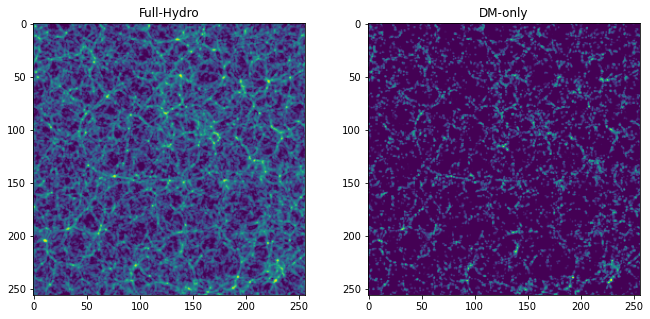

In [13]:
fig, ax = plt.subplots(1,2, figsize=(11,5))

ax[0].imshow(np.log10(1+grid_mtng[0,:,:,0]))
ax[1].imshow(np.log10(1+grid_dm_1080[0,:,:,0]))

ax[0].set_title('Full-Hydro')
ax[1].set_title('DM-only')

### Select the halos

In [15]:
hydro_split = utils.split_halos(mtng)
hydro_split.halo_sel_setup()

2026-05-01 22:51:12,895 bacco.sims : Reading 98233510 items for Group_M_Mean200
2026-05-01 22:51:47,063 bacco.sims : Reading 90246895 items for SubhaloVmax
2026-05-01 22:52:45,221 bacco.sims : Reading 98233510 items for halo_firstsub


### Define ranges of halo mass

In [16]:
mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

In [17]:
mass_edges = np.array(list(zip(mbins[:-1], mbins[1:])))

In [24]:
sel_total = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=None)

In [23]:
ens_sel = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=1, draws=100)

### SMF for these selections

In [25]:
nbins=15

In [26]:
ens_smf = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_smf_draws(sel_mask=ens_sel, nbins=nbins, draws=100, m_30kpc=False)

for i in range(100):
    ens_smf[i] = temp['smf'][i]
    ens_mstar[i] = temp['mstar'][i]
    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_smf[i][np.where(np.isnan(ens_mstar[i]))] = 0

2026-05-01 22:58:54,571 bacco.sims : Reading 98233510 items for GroupNsubs


2026-05-01 22:58:57,611 bacco.sims : Reading 90246895 items for SubhaloMassType
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:431: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] = mstar_mean[d] / counts[d]


In [27]:
mean_smf   = np.sum(ens_smf, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_smf    = np.sqrt( np.sum(ens_smf**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_smf, axis=0) / np.sum(weights, axis=0) )**2 )

In [62]:
np.nanstd(ens_smf, axis=0)

array([6.08425507e-04, 4.85791691e-04, 4.77481320e-04, 4.47557823e-04,
       3.21447060e-04, 2.53096640e-04, 2.26034977e-04, 1.85078878e-04,
       1.60993416e-04, 9.64447781e-05, 5.57141309e-05, 3.28522496e-05,
       1.66708520e-05, 6.20062265e-06])

In [28]:
smf_total = hydro_split.total_smf(nbins=nbins)

2026-05-01 22:59:39,502 bacco.sims : Reading the host halo properties of the subhaloes
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:86: RuntimeWarning: divide by zero encountered in log10
  sel = np.log10(1e10 * self.sim.fof['halo_m200b'][self.sim.sub['parent_halo']['index']]) > 9


In [29]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

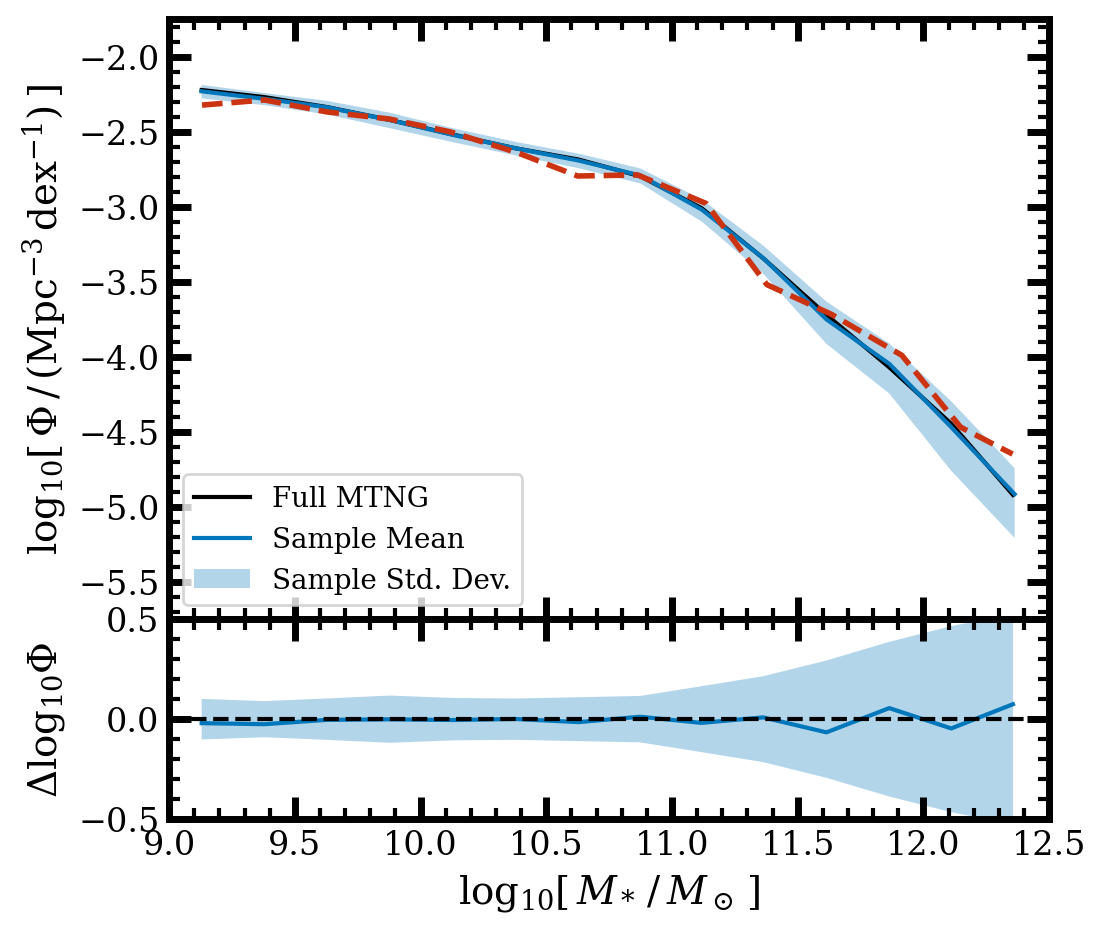

In [30]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#0077BB', '#009988', '#CC3311', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_ylabel(r'$\log_{10}[\,\Phi\,/\,(\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1})\,]$', fontsize=14)

ax1.set_xlim(9,12.5)
ax1.set_ylim(-5.75, -1.75)

ax1.plot(np.log10(smf_total['mstar']), np.log10(smf_total['smf']), label='Full MTNG', color='k')
ax1.plot(np.log10(mean_mstar), np.log10(mean_smf), color=colors[0], label='Sample Mean') 
ax1.fill_between(np.log10(mean_mstar), np.log10(mean_smf-err_smf), np.log10(mean_smf+err_smf), color=colors[0], alpha=0.3, edgecolor=None, label='Sample Std. Dev.')

ax1.plot(np.log10(ens_mstar[0]), np.log10(ens_smf[0]), color=colors[2], ls='--', lw=2)

ax1.legend(loc='lower left')

plt.setp(ax1.get_xticklabels(), visible=False)

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(9,12.5)
ax2.set_ylim(-0.5,0.5)

ax2.plot(np.log10(smf_total['mstar']), np.interp(smf_total['mstar'], mean_mstar, mean_smf)/smf_total['smf'] - 1, color=colors[0])
ax2.fill_between(np.log10(smf_total['mstar']), -np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], color=colors[0], alpha=0.3, edgecolor=None)
ax2.axhline(0, ls='--', color='k')

ax2.set_xlabel(r'$\log_{10}[\,M_*\,/\,M_\odot\,]$', fontsize=14)
ax2.set_ylabel(r'$\Delta\log_{10}\Phi$', fontsize=14)

for ax in [ax1, ax2]:
    # Thicker plot edges
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    # Major and minor ticks
    ax.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, top=True, right=True, direction='in')
    ax.tick_params(axis='both', which='minor', width=1.5, length=4, top=True, right=True, direction='in')
    ax.minorticks_on()



## What about gas-fraction

In [37]:
fgas_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_draws/fgas_draws100_nbins10.npy", allow_pickle=True).item()
err_fgas = np.std(fgas_draws['ens_fgas'], axis=0)

Text(0, 0.5, '$f_\\mathrm{gas}$')

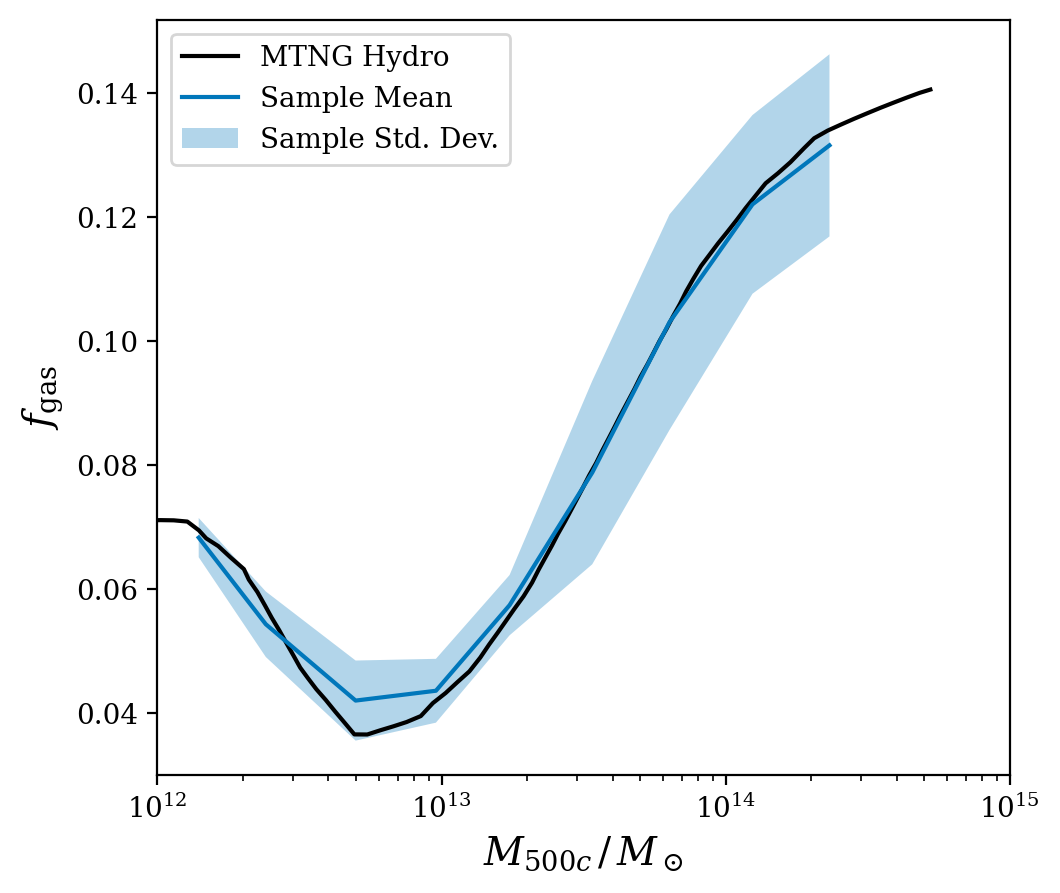

In [55]:
# Fantastic, you did it Claude, you magnificent bastard
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')

ax.set_xlim(1e12, 1e15)

ax.plot(mtng_gas_frac[:,0], mtng_gas_frac[:,1], color='k', label='MTNG Hydro')

ax.plot(np.mean(fgas_draws['m500'], axis=0), np.mean(fgas_draws['ens_fgas'], axis=0), color=colors[0], label='Sample Mean')
ax.fill_between(np.mean(fgas_draws['m500'], axis=0), np.mean(fgas_draws['ens_fgas'], axis=0)-err_fgas, np.mean(fgas_draws['ens_fgas'], axis=0)+err_fgas, color=colors[0], alpha=0.3, edgecolor=None, label='Sample Std. Dev.')

ax.legend(loc='upper left')

ax.set_xlabel(r'$M_{500c}\,/\,M_\odot$', fontsize=14)
ax.set_ylabel(r'$f_\mathrm{gas}$', fontsize=14)

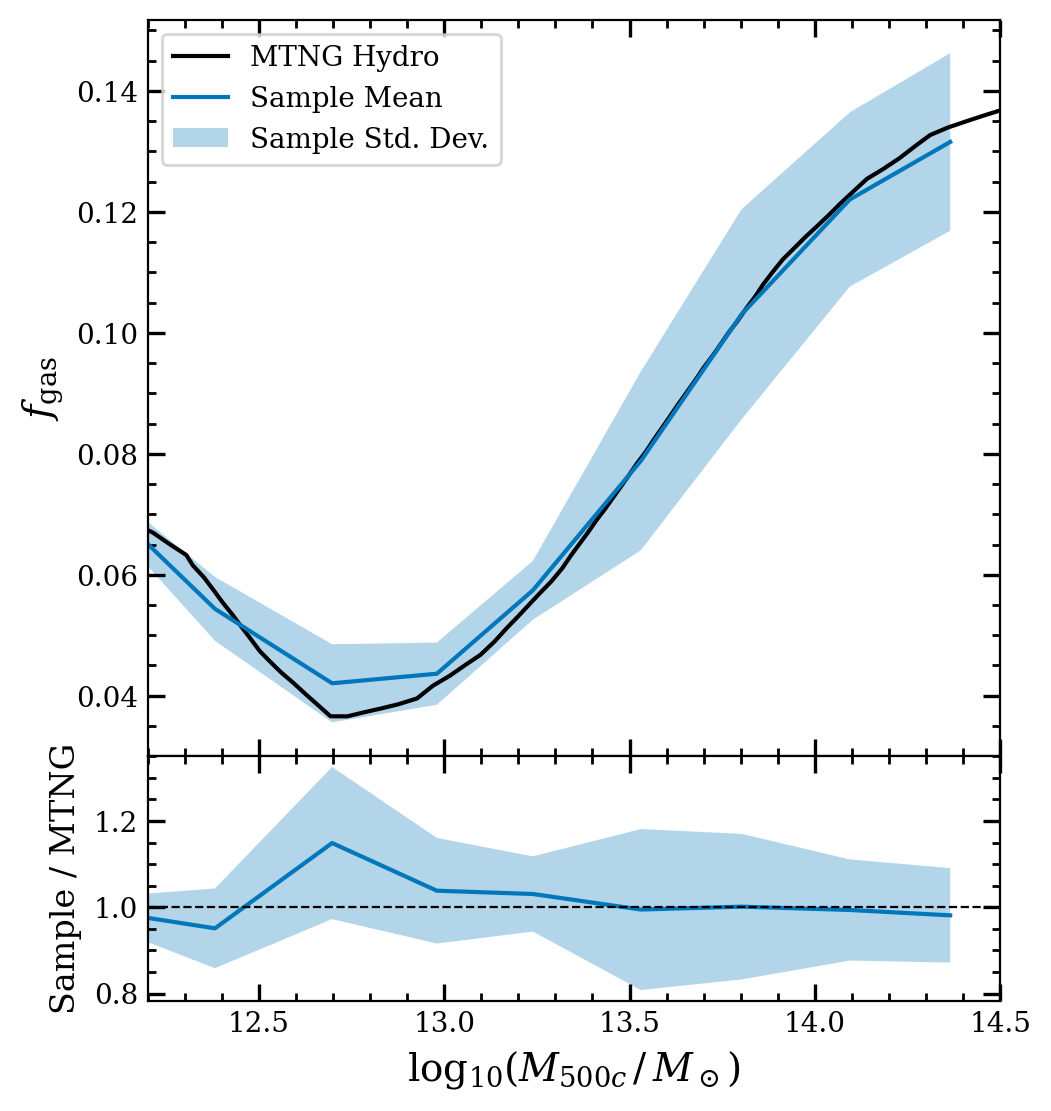

In [61]:
from matplotlib.ticker import AutoMinorLocator
import numpy as np

fig, (ax, axr) = plt.subplots(2, 1, dpi=200, figsize=(5.5, 6.5),
                              sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax.set_xlim(12.2, 14.5)

ax.plot(np.log10(mtng_gas_frac[:,0]), mtng_gas_frac[:,1], color='k', label='MTNG Hydro')

m500_mean = np.mean(fgas_draws['m500'], axis=0)
fgas_mean = np.mean(fgas_draws['ens_fgas'], axis=0)
log_m500 = np.log10(m500_mean)

ax.plot(log_m500, fgas_mean, color=colors[0], label='Sample Mean')
ax.fill_between(log_m500, fgas_mean - err_fgas, fgas_mean + err_fgas,
                color=colors[0], alpha=0.3, edgecolor=None, label='Sample Std. Dev.')

ax.legend(loc='upper left')
ax.set_ylabel(r'$f_\mathrm{gas}$', fontsize=14)

# Ratio panel
mtng_interp = np.interp(m500_mean, mtng_gas_frac[:,0], mtng_gas_frac[:,1])
ratio = fgas_mean / mtng_interp
ratio_err = err_fgas / mtng_interp

axr.plot(log_m500, ratio, color=colors[0])
axr.fill_between(log_m500, ratio - ratio_err, ratio + ratio_err,
                 color=colors[0], alpha=0.3, edgecolor=None)
axr.axhline(1.0, color='k', lw=0.8, ls='--')

axr.set_xlabel(r'$\log_{10}(M_{500c}\,/\,M_\odot)$', fontsize=14)
axr.set_ylabel('Sample / MTNG', fontsize=12)

for a in (ax, axr):
    a.tick_params(which='both', direction='in', top=True, right=True,
                  width=1.2, length=6)
    a.tick_params(which='minor', length=3, width=1.0)
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())

In [48]:
np.std(fgas_draws['ens_fgas'], axis=0)

array([0.00316438, 0.00528121, 0.00645732, 0.00514671, 0.00486182,
       0.01478198, 0.01737385, 0.0144077 , 0.01468625])

In [115]:
gas_pos = mtng.gas['pos']
boxsize = 500

In [116]:
print('gas_pos min:', gas_pos.min())
print('gas_pos max:', gas_pos.max())
print('boxsize:', boxsize)
print('any >= boxsize:', np.any(gas_pos >= boxsize))
print('any < 0:', np.any(gas_pos < 0))

gas_pos min: 0.0
gas_pos max: 500.0
boxsize: 500
any >= boxsize: True
any < 0: False


In [31]:
mean_fgas   = np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0)
mean_m500 = np.sum(ens_m500, axis=0) / np.sum(weights, axis=0)
err_fgas    = np.sqrt( np.sum(ens_fgas**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0) )**2 )

In [32]:
fgas_total = hydro_split.total_gas_frac(m500_edges=m500_edges, mass_edges=mass_edges)

In [ ]:
fgas_total

Text(0.5, 0, '$M_{500,c}[M_\\odot h^{-1}]$')

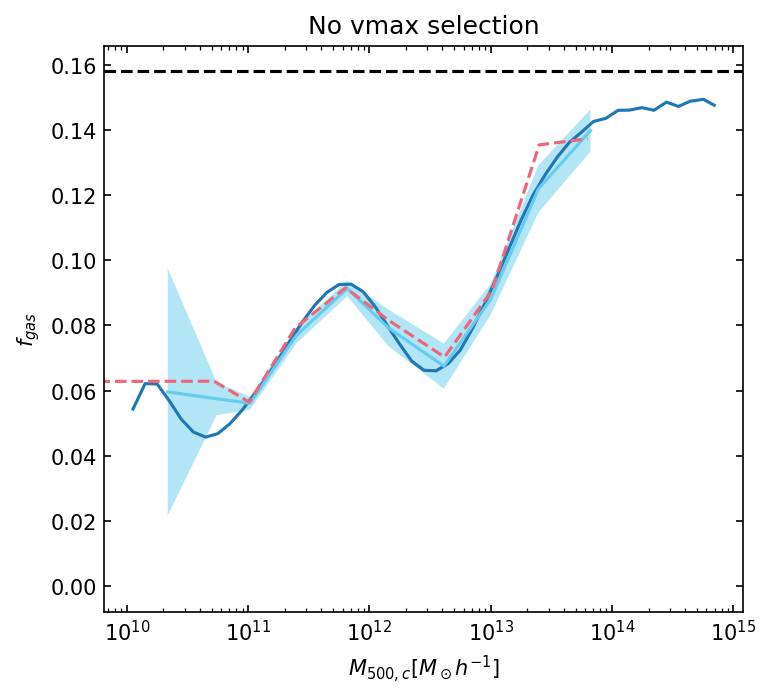

In [33]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')

ax.plot(fgas_total['m500'], fgas_total['f_gas'])
ax.plot(mean_m500, mean_fgas, color=colors[1])
# ax.plot(ens_m500[3], ens_fgas[3], color=colors[2], ls='--')
ax.plot(ens_m500[28], ens_fgas[28], color=colors[4], ls='--')

ax.fill_between(mean_m500, mean_fgas-err_fgas, mean_fgas+err_fgas, color=colors[1], alpha=0.5, edgecolor=None)
    
ax.axhline(0.158, color='k', ls='--')

ax.set_title('No vmax selection')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500,c}[M_\\odot h^{-1}]$')

In [34]:
sfr_mstar = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=20)

2024-08-02 14:44:22,327 bacco.sims : Reading 90246895 items for SubhaloSFR
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: invalid value encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: divide by zero encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:337: RuntimeWarning: invalid value encountered in divide
  sSFR_mean[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:338: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] /= counts[d]


In [65]:
def mean_std_without_zeros(array):
    ndraws, nbins = array.shape
    mean_values = []
    std_values = []

    for i in range(nbins):
        non_zero_values = array[:, i][array[:, i] != 0]
        mean_values.append(np.mean(non_zero_values))
        std_values.append(np.std(non_zero_values))

    return np.array(mean_values), np.array(std_values)


In [66]:
fgas_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_draws/fgas_draws100_nbins10.npy", allow_pickle=True).item()
mean_fgas, err_fgas = mean_std_without_zeros(fgas_draws['ens_fgas'])
mean_m500c, _ = mean_std_without_zeros(fgas_draws['m500'])

In [70]:
smf_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_draws/smf_draws100_nbins10.npy", allow_pickle=True).item()

mean_smf_nz, err_smf_nz = mean_std_without_zeros(smf_draws['ens_smf'])
err_log_smf = err_smf_nz / mean_smf_nz / np.log(10)
mstar_mean, _ = mean_std_without_zeros(smf_draws['mstar'])